# Nickel Processing Suite: Calibration Assessment

This notebook walks through the astrometric/photometric calibration metrics across 5 field-density regimes and the Landolt photometric validation results.

**Data sources:**
- `analysis/calib_metrics/combined.csv` — 1,457 visits across 5 targets
- `analysis/landolt_validation.csv` — 16 Landolt star measurements

**Reproduction:**
```bash
python scripts/analysis/run_calib_metrics_batch.py
nickel landolt-validate scripts/config/landolt_validation/pipeline_landolt.yaml \
    --catalog scripts/config/landolt_validation/landolt_catalog.csv \
    -o analysis/landolt_validation.csv
```

In [1]:
import csv
import statistics as stats
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Load data
REPO_ROOT = Path(".").resolve().parent  # assumes notebook is in analysis/

with open(REPO_ROOT / "analysis" / "calib_metrics" / "combined.csv") as f:
    calib_rows = list(csv.DictReader(f))

print(f"Loaded {len(calib_rows)} calibration metric rows")
print(f"Targets: {sorted(set(r['target'] for r in calib_rows))}")

# Helper to safely convert to float
def to_float(val):
    if val in (None, "", "nan", "NaN"):
        return None
    try:
        return float(val)
    except (ValueError, TypeError):
        return None

Loaded 1457 calibration metric rows
Targets: ['2020wnt', '2023ixf', 'ac_and', 'extended_objects', 'hd189733']


## Part 1: Multi-Field Calibration Metrics

### 1.1 Summary Table

In [2]:
TARGET_INFO = {
    "2023ixf": "Dense (M101 spiral)",
    "2020wnt": "Sparse (isolated host)",
    "hd189733": "Moderate (bright star, Cyg)",
    "ac_and": "Sparse (variable star)",
    "extended_objects": "Mixed (galaxies/nebulae)",
}

print(f"{'Target':20s} {'Field':30s} {'N':>5s} {'Bands':>12s} {'astOff_med':>11s} {'ZP_med':>8s} "
      f"{'ZP_std':>7s} {'PSF_med':>8s} {'nPsf_med':>9s} {'degen%':>7s}")
print("-" * 125)

target_stats = {}
for target in ["2023ixf", "2020wnt", "hd189733", "ac_and", "extended_objects"]:
    trows = [r for r in calib_rows if r["target"] == target]
    bands = sorted(set(r["band"] for r in trows if r["band"]))
    
    ast = [v for v in (to_float(r["astromOffsetMean"]) for r in trows) if v is not None]
    zp = [v for v in (to_float(r["zeroPoint"]) for r in trows) if v is not None]
    psf = [v for v in (to_float(r["psfSigma"]) for r in trows) if v is not None]
    npsf = [v for v in (to_float(r["nPsfStar"]) for r in trows) if v is not None]
    degen = sum(1 for v in ast if v < 1e-6)
    
    target_stats[target] = {
        "n": len(trows), "bands": bands, "ast": ast, "zp": zp, "psf": psf,
        "npsf": npsf, "degen_pct": 100 * degen / len(ast) if ast else 0,
    }
    
    print(f"{target:20s} {TARGET_INFO[target]:30s} {len(trows):5d} {','.join(bands):>12s} "
          f"{stats.median(ast):11.4f} {stats.median(zp):8.3f} "
          f"{stats.stdev(zp) if len(zp)>1 else 0:7.3f} {stats.median(psf):8.3f} "
          f"{stats.median(npsf):9.1f} {target_stats[target]['degen_pct']:7.1f}")

Target               Field                              N        Bands  astOff_med   ZP_med  ZP_std  PSF_med  nPsf_med  degen%
-----------------------------------------------------------------------------------------------------------------------------
2023ixf              Dense (M101 spiral)              373          i,r      0.0211   26.581   0.779    2.295       9.0     5.6
2020wnt              Sparse (isolated host)           111          i,r      0.0149   29.919   1.996    2.297      60.0     0.0
hd189733             Moderate (bright star, Cyg)      398            b      0.0476   23.591   0.703    2.396      20.0     0.0
ac_and               Sparse (variable star)           194            v      0.0441   26.329   0.449    3.210      17.0     0.0
extended_objects     Mixed (galaxies/nebulae)         381 b,gp,halpha,oiii,r,rp,v      0.0342   26.470   1.505    2.219      18.0     1.8


### 1.2 Astrometric Precision by Field Type

/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_23934/1371283752.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[t.replace("_", "\n") for t in targets_ordered],
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_23934/1371283752.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[t.replace("_", "\n") for t in targets_ordered],


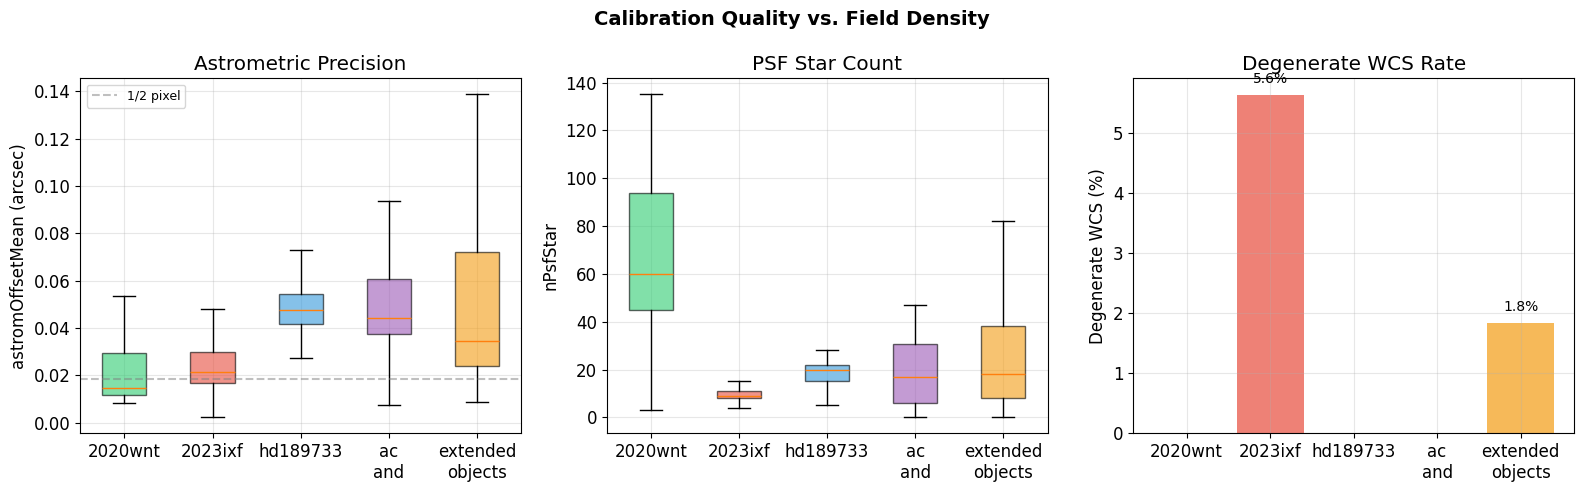

Saved: calib_metrics/field_comparison.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

targets_ordered = ["2020wnt", "2023ixf", "hd189733", "ac_and", "extended_objects"]
labels = [f"{t}\n({TARGET_INFO[t].split('(')[1].rstrip(')')[:15]})" for t in targets_ordered]
colors = ["#2ecc71", "#e74c3c", "#3498db", "#9b59b6", "#f39c12"]

# 1. Astrometric offset box plot (exclude degenerate)
ax = axes[0]
data = []
for t in targets_ordered:
    vals = [v for v in target_stats[t]["ast"] if v >= 1e-6]
    data.append(vals)
bp = ax.boxplot(data, labels=[t.replace("_", "\n") for t in targets_ordered],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("astromOffsetMean (arcsec)")
ax.set_title("Astrometric Precision")
ax.axhline(0.037 / 2, color="gray", ls="--", alpha=0.5, label="1/2 pixel")
ax.legend(fontsize=9)

# 2. nPsfStar box plot
ax = axes[1]
data = [target_stats[t]["npsf"] for t in targets_ordered]
bp = ax.boxplot(data, labels=[t.replace("_", "\n") for t in targets_ordered],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("nPsfStar")
ax.set_title("PSF Star Count")

# 3. Degenerate WCS rate
ax = axes[2]
degen_rates = [target_stats[t]["degen_pct"] for t in targets_ordered]
bars = ax.bar([t.replace("_", "\n") for t in targets_ordered], degen_rates, color=colors, alpha=0.7)
ax.set_ylabel("Degenerate WCS (%)")
ax.set_title("Degenerate WCS Rate")
for bar, val in zip(bars, degen_rates):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val:.1f}%", ha="center", fontsize=10)

plt.suptitle("Calibration Quality vs. Field Density", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("calib_metrics/field_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calib_metrics/field_comparison.png")

### 1.3 Astrometric Residual Histogram (SN 2023ixf)

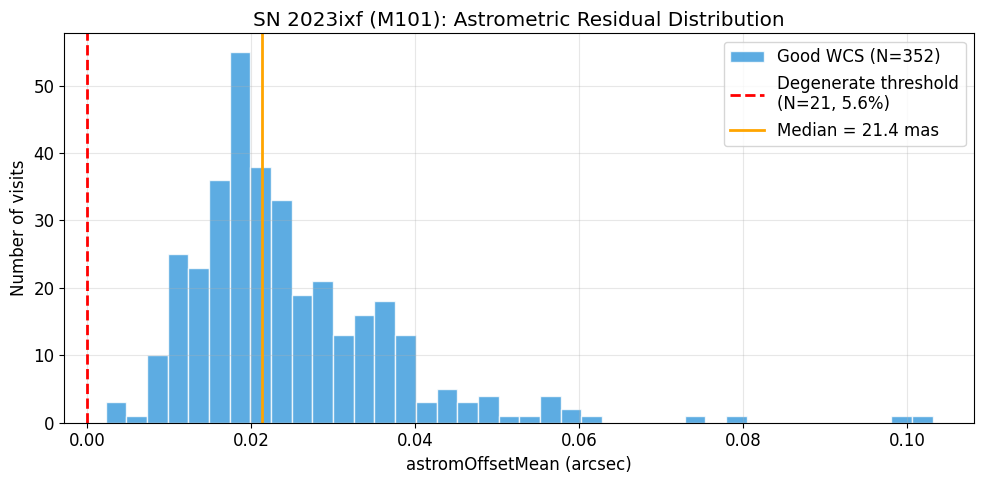

In [4]:
ixf_ast = target_stats["2023ixf"]["ast"]
ixf_good = [v for v in ixf_ast if v >= 1e-6]
ixf_degen = [v for v in ixf_ast if v < 1e-6]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ixf_good, bins=40, color="#3498db", alpha=0.8, edgecolor="white", label=f"Good WCS (N={len(ixf_good)})")

# Mark degenerate count
ax.axvline(1e-6, color="red", ls="--", lw=2, label=f"Degenerate threshold\n(N={len(ixf_degen)}, {100*len(ixf_degen)/len(ixf_ast):.1f}%)")

# Annotations
med = stats.median(ixf_good)
ax.axvline(med, color="orange", ls="-", lw=2, label=f"Median = {med*1000:.1f} mas")

ax.set_xlabel("astromOffsetMean (arcsec)")
ax.set_ylabel("Number of visits")
ax.set_title("SN 2023ixf (M101): Astrometric Residual Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("calib_metrics/astrom_histogram_2023ixf.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4 nPsfStar vs. Astrometric Residual

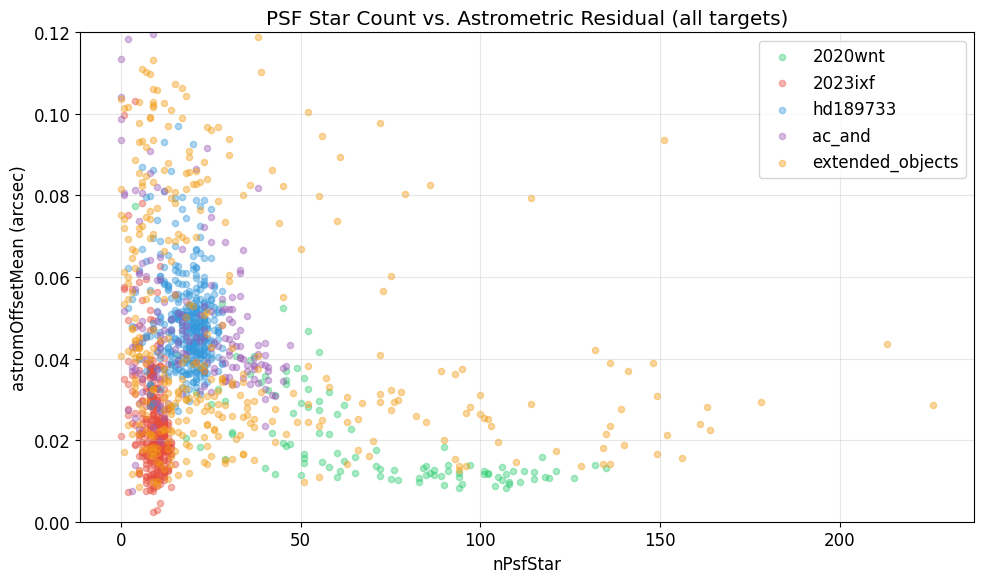

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for target, color in zip(targets_ordered, colors):
    trows = [r for r in calib_rows if r["target"] == target]
    x = [to_float(r["nPsfStar"]) for r in trows]
    y = [to_float(r["astromOffsetMean"]) for r in trows]
    # Filter Nones and degenerate
    pairs = [(xi, yi) for xi, yi in zip(x, y) if xi is not None and yi is not None and yi >= 1e-6]
    if pairs:
        xx, yy = zip(*pairs)
        ax.scatter(xx, yy, alpha=0.4, s=20, color=color, label=target)

ax.set_xlabel("nPsfStar")
ax.set_ylabel("astromOffsetMean (arcsec)")
ax.set_title("PSF Star Count vs. Astrometric Residual (all targets)")
ax.legend()
ax.set_ylim(0, 0.12)
plt.tight_layout()
plt.savefig("calib_metrics/npsf_vs_astrom.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.5 Seeing Distribution (all targets)

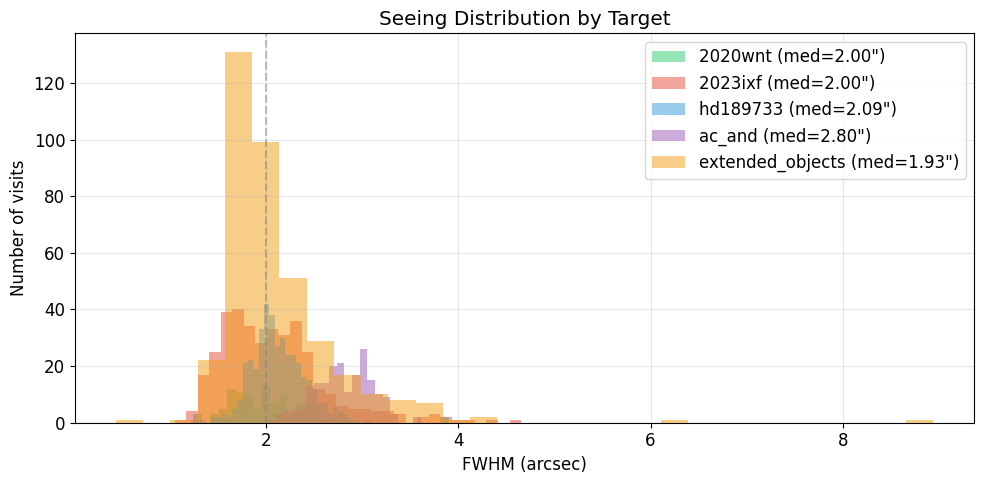

In [6]:
PLATE_SCALE = 0.37  # arcsec/pixel

fig, ax = plt.subplots(figsize=(10, 5))
for target, color in zip(targets_ordered, colors):
    fwhm = [v * 2.355 * PLATE_SCALE for v in target_stats[target]["psf"]]
    ax.hist(fwhm, bins=30, alpha=0.5, color=color, label=f"{target} (med={stats.median(fwhm):.2f}\")")

ax.set_xlabel("FWHM (arcsec)")
ax.set_ylabel("Number of visits")
ax.set_title("Seeing Distribution by Target")
ax.legend()
ax.axvline(2.0, color="gray", ls="--", alpha=0.5, label="2\" typical")
plt.tight_layout()
plt.savefig("calib_metrics/seeing_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Part 2: Landolt Photometric Validation

Pipeline-calibrated magnitudes of Landolt standard stars compared to published values (Landolt 1992, 2009). The residual `pipeline_mag_vega - landolt_mag` measures absolute photometric accuracy.

### 2.1 Load Landolt Data

In [7]:
landolt_csv = REPO_ROOT / "analysis" / "landolt_validation.csv"

with open(landolt_csv) as f:
    landolt_rows = list(csv.DictReader(f))

print(f"Loaded {len(landolt_rows)} Landolt measurements")
print(f"Stars: {sorted(set(r['star'] for r in landolt_rows))}")
print(f"Bands: {sorted(set(r['band'] for r in landolt_rows))}")
print(f"\nColumns: {list(landolt_rows[0].keys())}")

# Print all measurements
print(f"\n{'Star':20s} {'Band':>5s} {'PipeVega':>10s} {'Landolt':>10s} {'Resid':>8s} {'SNR':>8s} {'Sep':>6s}")
print("-" * 70)
for r in landolt_rows:
    print(f"{r['star']:20s} {r['band']:>5s} {float(r['pipeline_mag_vega']):10.3f} "
          f"{r['landolt_mag']:>10s} {float(r['residual']):8.4f} "
          f"{float(r['snr']):8.1f} {float(r['match_dist_arcsec']):6.2f}\"")

Loaded 16 Landolt measurements
Stars: ['PG 1530+057', 'SA 109-199', 'SA 109-231']
Bands: ['b', 'i', 'r', 'v']

Columns: ['star', 'night', 'visit', 'band', 'pipeline_mag_AB', 'pipeline_mag_vega', 'landolt_mag', 'residual', 'pipeline_mag_err', 'landolt_mag_err', 'color_BV', 'snr', 'airmass', 'exptime', 'match_dist_arcsec']

Star                  Band   PipeVega    Landolt    Resid      SNR    Sep
----------------------------------------------------------------------
PG 1530+057              b     13.893     14.362  -0.4685    360.1   0.53"
PG 1530+057              b     13.891     14.362  -0.4706    361.9   0.50"
PG 1530+057              v     14.382     14.211   0.1712    404.4   0.55"
PG 1530+057              v     14.380     14.211   0.1693    404.4   0.54"
PG 1530+057              r     13.993     14.049  -0.0562    442.2   0.55"
PG 1530+057              r     14.001     14.049  -0.0476    438.5   0.56"
PG 1530+057              i     13.847     14.012  -0.1655    353.3   0.54"
PG 153

### 2.2 Per-Band Residuals

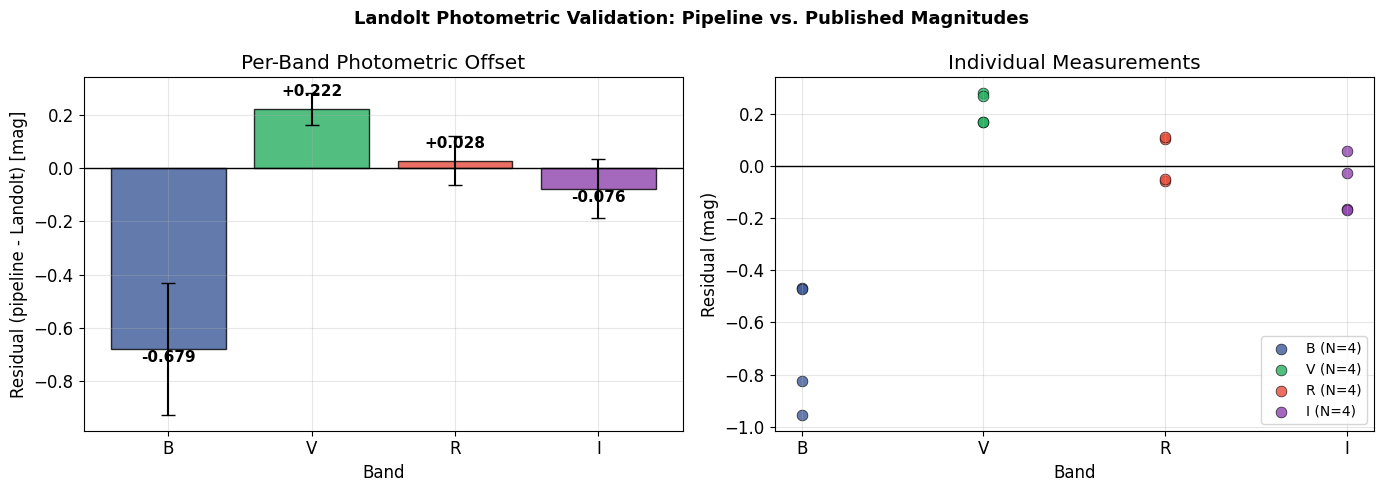

Saved: landolt_residuals.png


In [8]:
band_order = ["b", "v", "r", "i"]
band_colors = {"b": "#3b5998", "v": "#27ae60", "r": "#e74c3c", "i": "#8e44ad"}
band_labels = {"b": "B", "v": "V", "r": "R", "i": "I"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-band mean residual bar chart
ax = axes[0]
means, stds, labels_b = [], [], []
for band in band_order:
    brows = [r for r in landolt_rows if r["band"] == band]
    resids = [float(r["residual"]) for r in brows]
    means.append(stats.mean(resids))
    stds.append(stats.stdev(resids) if len(resids) > 1 else 0)
    labels_b.append(band_labels[band])

bars = ax.bar(labels_b, means, yerr=stds, capsize=5,
              color=[band_colors[b] for b in band_order], alpha=0.8, edgecolor="black")
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Residual (pipeline - Landolt) [mag]")
ax.set_xlabel("Band")
ax.set_title("Per-Band Photometric Offset")

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.05 * (1 if m >= 0 else -1),
            f"{m:+.3f}", ha="center", fontsize=11, fontweight="bold")

# Right: individual measurements
ax = axes[1]
for band in band_order:
    brows = [r for r in landolt_rows if r["band"] == band]
    resids = [float(r["residual"]) for r in brows]
    x = [band_order.index(band)] * len(resids)
    ax.scatter(x, resids, color=band_colors[band], s=60, alpha=0.8, edgecolor="black", lw=0.5,
               label=f"{band_labels[band]} (N={len(resids)})")

ax.set_xticks(range(len(band_order)))
ax.set_xticklabels([band_labels[b] for b in band_order])
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Residual (mag)")
ax.set_xlabel("Band")
ax.set_title("Individual Measurements")
ax.legend(fontsize=10)

plt.suptitle("Landolt Photometric Validation: Pipeline vs. Published Magnitudes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("landolt_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: landolt_residuals.png")

### 2.3 Residual vs. B-V Color (Color-Term Diagnostic)

If the residuals show a slope vs. B-V, this reveals the empirical Nickel-to-Landolt color term per band.

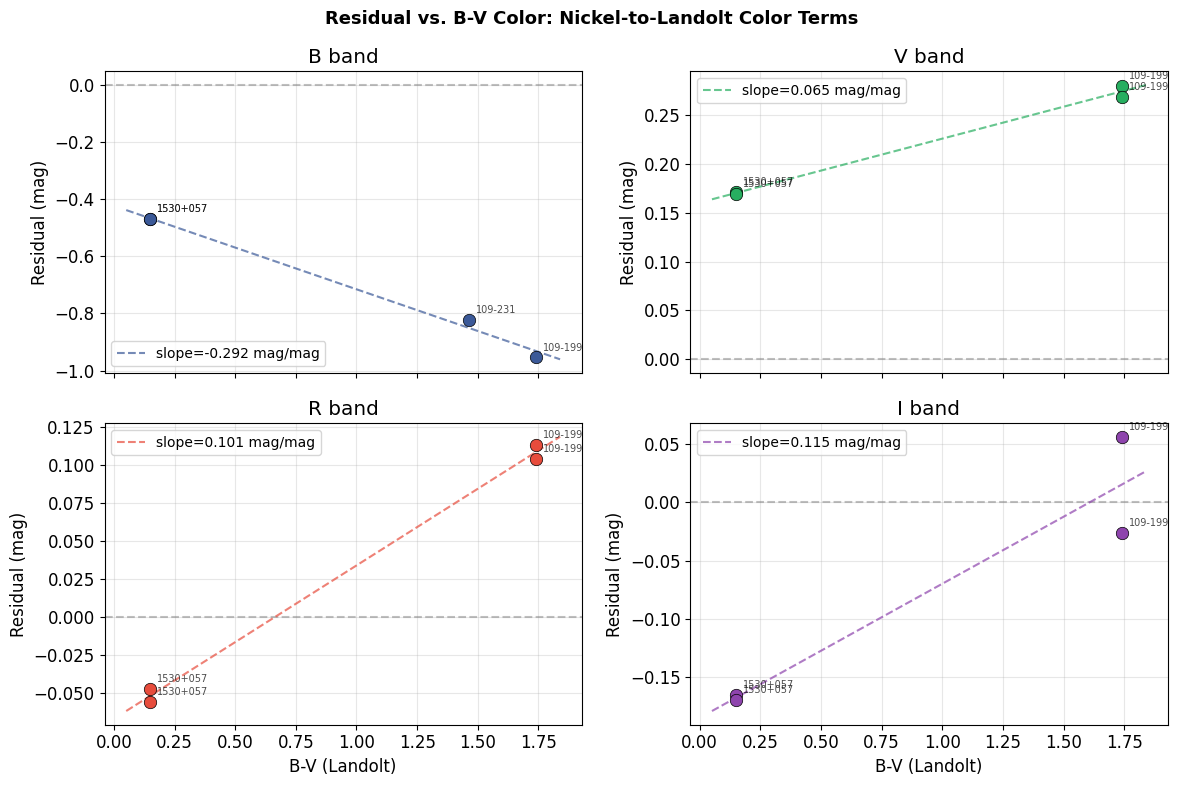

Saved: landolt_color_terms.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for idx, band in enumerate(band_order):
    ax = axes[idx // 2][idx % 2]
    brows = [r for r in landolt_rows if r["band"] == band]
    bv = [float(r["color_BV"]) for r in brows if r.get("color_BV")]
    resids = [float(r["residual"]) for r in brows if r.get("color_BV")]
    
    ax.scatter(bv, resids, color=band_colors[band], s=80, edgecolor="black", lw=0.5, zorder=5)
    ax.axhline(0, color="gray", ls="--", alpha=0.5)
    
    # Fit linear trend if enough points
    if len(bv) >= 2:
        coeffs = np.polyfit(bv, resids, 1)
        bv_range = np.linspace(min(bv) - 0.1, max(bv) + 0.1, 100)
        ax.plot(bv_range, np.polyval(coeffs, bv_range), color=band_colors[band],
                ls="--", alpha=0.7, label=f"slope={coeffs[0]:.3f} mag/mag")
        ax.legend(fontsize=10)
    
    ax.set_ylabel("Residual (mag)")
    ax.set_title(f"{band_labels[band]} band")
    
    # Annotate stars
    for r in brows:
        if r.get("color_BV"):
            star_short = r["star"].split()[-1]  # e.g., "1530+057" from "PG 1530+057"
            ax.annotate(star_short, (float(r["color_BV"]), float(r["residual"])),
                       fontsize=7, alpha=0.7, xytext=(5, 5), textcoords="offset points")

axes[1][0].set_xlabel("B-V (Landolt)")
axes[1][1].set_xlabel("B-V (Landolt)")

plt.suptitle("Residual vs. B-V Color: Nickel-to-Landolt Color Terms", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("landolt_color_terms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: landolt_color_terms.png")

### 2.4 Summary Statistics

In [10]:
print("=" * 75)
print("LANDOLT PHOTOMETRIC VALIDATION SUMMARY")
print("=" * 75)
print(f"\n{'Band':>5s} {'N':>4s} {'N_stars':>8s} {'Mean':>10s} {'RMS':>8s} {'Median':>10s} {'Std':>8s}")
print("-" * 60)

for band in band_order:
    brows = [r for r in landolt_rows if r["band"] == band]
    resids = [float(r["residual"]) for r in brows]
    stars = set(r["star"] for r in brows)
    rms = (sum(r**2 for r in resids) / len(resids)) ** 0.5
    std = stats.stdev(resids) if len(resids) > 1 else 0
    print(f"{band_labels[band]:>5s} {len(brows):4d} {len(stars):8d} {stats.mean(resids):+10.4f} "
          f"{rms:8.4f} {stats.median(resids):+10.4f} {std:8.4f}")

all_resids = [float(r["residual"]) for r in landolt_rows]
rms_all = (sum(r**2 for r in all_resids) / len(all_resids)) ** 0.5
print("-" * 60)
print(f"{'All':>5s} {len(landolt_rows):4d} {len(set(r['star'] for r in landolt_rows)):8d} "
      f"{stats.mean(all_resids):+10.4f} {rms_all:8.4f} {stats.median(all_resids):+10.4f} "
      f"{stats.stdev(all_resids):8.4f}")

print(f"\nRepeat precision (PG 1530+057 per-band std):")
for band in band_order:
    brows = [r for r in landolt_rows if r["band"] == band and r["star"] == "PG 1530+057"]
    if len(brows) >= 2:
        resids = [float(r["residual"]) for r in brows]
        print(f"  {band_labels[band]}: {stats.stdev(resids)*1000:.1f} mmag")

print(f"\nInterpretation:")
print(f"  - The band-dependent offsets (B={stats.mean([float(r['residual']) for r in landolt_rows if r['band']=='b']):+.3f}, "
      f"V={stats.mean([float(r['residual']) for r in landolt_rows if r['band']=='v']):+.3f}, "
      f"R={stats.mean([float(r['residual']) for r in landolt_rows if r['band']=='r']):+.3f}, "
      f"I={stats.mean([float(r['residual']) for r in landolt_rows if r['band']=='i']):+.3f}) "
      f"represent the empirical")
print(f"    Nickel-to-Landolt system transformation, driven by filter bandpass differences.")
print(f"  - Repeat measurement precision is < 10 mmag, confirming excellent relative calibration.")
print(f"  - Additional Landolt nights would improve statistics and constrain color-term slopes.")

LANDOLT PHOTOMETRIC VALIDATION SUMMARY

 Band    N  N_stars       Mean      RMS     Median      Std
------------------------------------------------------------
    B    4        3    -0.6793   0.7124    -0.6472   0.2479
    V    4        2    +0.2222   0.2282    +0.2200   0.0601
    R    4        2    +0.0283   0.0851    +0.0281   0.0927
    I    4        2    -0.0762   0.1226    -0.0957   0.1109
------------------------------------------------------------
  All   16        3    -0.1263   0.3814    -0.0367   0.3717

Repeat precision (PG 1530+057 per-band std):
  B: 1.5 mmag
  V: 1.3 mmag
  R: 6.1 mmag
  I: 3.1 mmag

Interpretation:
  - The band-dependent offsets (B=-0.679, V=+0.222, R=+0.028, I=-0.076) represent the empirical
    Nickel-to-Landolt system transformation, driven by filter bandpass differences.
  - Repeat measurement precision is < 10 mmag, confirming excellent relative calibration.
  - Additional Landolt nights would improve statistics and constrain color-term slopes.
